### 1. Extracción de Datos (API de Steam)
Se importan las librerías necesarias y se realiza la petición a la API pública de Steam para extraer el conjunto de reseñas del juego objetivo (*Elden Ring*, ID: 1245620).

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de la petición a la API
app_id = '1245620'
url = f'https://store.steampowered.com/appreviews/{app_id}?json=1'

# Ejecución de la solicitud GET
respuesta = requests.get(url)
if respuesta.status_code == 200:
    datos = respuesta.json()
else:
    print(f"Error de conexión. Código: {respuesta.status_code}")

### 2. Estructuración de los Datos
Se transforma el formato JSON nativo de la API en un DataFrame de Pandas para permitir la manipulación tabular y el análisis descriptivo.

In [2]:
# Transformación a DataFrame
df = pd.DataFrame(datos['reviews'])
df.head()

,recommendationid,author,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,refunded,written_during_early_access,primarily_steam_deck,app_release_date,reactions,hardware
0,225971727,"{'steamid': '76561197983587835', 'personaname'...",english,This game is very addictive and it is huge! It...,1779254077,1779254077,True,91,4,0.862426042556762695,0,True,False,False,False,False,1645744078,"[{'reaction_type': 35, 'count': 8}, {'reaction...",NaN
1,226856833,"{'steamid': '76561198772807020', 'personaname'...",english,"[h3]A generational game, but not without flaws...",1780227239,1780234467,True,40,1,0.736802279949188232,5,True,False,False,False,False,1645744078,"[{'reaction_type': 27, 'count': 1}, {'reaction...",NaN
2,226958551,"{'steamid': '76561199037727615', 'personaname'...",english,Bought it late. Wish I hadn't waited. Played m...,1780336990,1780336990,True,20,2,0.697071194648742676,0,True,False,False,False,False,1645744078,"[{'reaction_type': 31, 'count': 1}, {'reaction...",NaN
3,227671874,"{'steamid': '76561199208398378', 'personaname'...",english,SILLY LORE/PLAYED BEFORE KNOWLEDGE I never pla...,1781127356,1781127356,True,7,1,0.59676671028137207,1,True,False,False,False,False,1645744078,[],"{'manufacturer': 'HP', 'model': 'Victus by HP ..."
4,227951786,"{'steamid': '76561199028864508', 'personaname'...",english,This game caused my wife and kids to leave me ...,1781445095,1781445095,False,13,34,0.586633086204528809,1,True,False,False,False,False,1645744078,"[{'reaction_type': 28, 'count': 1}, {'reaction...",NaN


### 3. Limpieza y Transformación de Datos
Se extrae la métrica de retención (horas jugadas) desde el formato de diccionario anidado en la columna `author`. Posteriormente, se eliminan las variables redundantes para optimizar la memoria del DataFrame.

In [3]:
# Extracción de playtime y conversión a horas
df['horas_jugadas'] = round(df['author'].apply(lambda x: x.get('playtime_forever', 0)) / 60, 2)

# Reducción de dimensionalidad
columnas_a_borrar = ['author', 'minutos_jugados', 'timestamp_updated']
df_limpio = df.drop(columns=columnas_a_borrar, errors='ignore')

df_limpio[['review', 'voted_up', 'horas_jugadas']].head()

,review,voted_up,horas_jugadas
0,This game is very addictive and it is huge! It...,True,309.03
1,"[h3]A generational game, but not without flaws...",True,83.95
2,Bought it late. Wish I hadn't waited. Played m...,True,277.58
3,SILLY LORE/PLAYED BEFORE KNOWLEDGE I never pla...,True,110.65
4,This game caused my wife and kids to leave me ...,False,471.95


### 4. Análisis de Retención y Segmentación
Se calcula la tendencia central de las horas jugadas segmentando por la satisfacción del usuario (promotores vs. detractores). Se emplea la mediana estadística para evitar el sesgo introducido por valores atípicos (*outliers*) de usuarios con miles de horas acumuladas.

In [4]:
# Cálculo de medianas por grupo de recomendación
analisis_retencion = df_limpio.groupby('voted_up')['horas_jugadas'].median()
print("Mediana de horas jugadas según recomendación:")
print(analisis_retencion)

# Segmentación y proporción de jugadores de alta retención (Hardcore)
jugadores_hardcore = df_limpio[df_limpio['horas_jugadas'] > 100]
porcentaje_hardcore = (len(jugadores_hardcore) / len(df_limpio)) * 100

print(f"\nProporción de reseñas emitidas por jugadores con más de 100 horas: {porcentaje_hardcore:.2f}%")

Mediana de horas jugadas según recomendación:
voted_up
False    471.95
True     171.10
Name: horas_jugadas, dtype: float64

Proporción de reseñas emitidas por jugadores con más de 100 horas: 70.00%


### 5. Visualización de Resultados
Representación gráfica del fenómeno analítico de retención: contraste entre la inversión de tiempo de los usuarios promotores frente a la de los detractores.

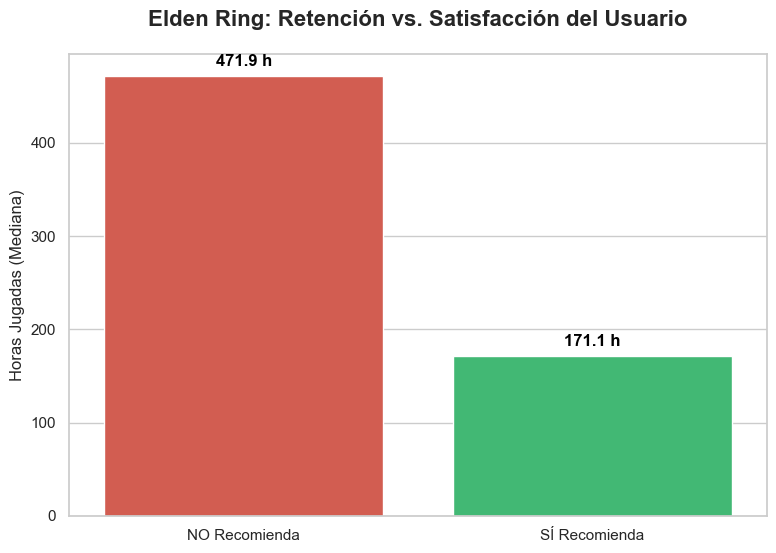

In [5]:
# Configuración del estilo visual
sns.set_theme(style="whitegrid")

# Preparación de datos para el gráfico
df_grafico = analisis_retencion.reset_index()
df_grafico['Recomendación'] = df_grafico['voted_up'].map({True: 'SÍ Recomienda', False: 'NO Recomienda'})

# Generación del gráfico de barras
plt.figure(figsize=(9, 6))
grafico = sns.barplot(
    x='Recomendación', 
    y='horas_jugadas', 
    data=df_grafico, 
    hue='Recomendación',
    palette={'SÍ Recomienda': '#2ecc71', 'NO Recomienda': '#e74c3c'},
    legend=False
)

# Inserción de títulos y formato de ejes
plt.title('Elden Ring: Retención vs. Satisfacción del Usuario', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('')
plt.ylabel('Horas Jugadas (Mediana)', fontsize=12)

# Inserción de etiquetas de datos exactos sobre las barras
for p in grafico.patches:
    grafico.annotate(f"{p.get_height():.1f} h", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', 
                     fontsize=12, fontweight='bold', color='black',
                     xytext=(0, 5), textcoords='offset points')

plt.show()